In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')

In [2]:
from crossgoose.model.models import CrossGooseModel

model  = CrossGooseModel.load_model(model='default')
model.eval();

loaded model from /home/jmabon/Documents/CODE/cross-goose/crossgoose/model/../saved_models/default/weights.ckpt


ran detection in 0.24s


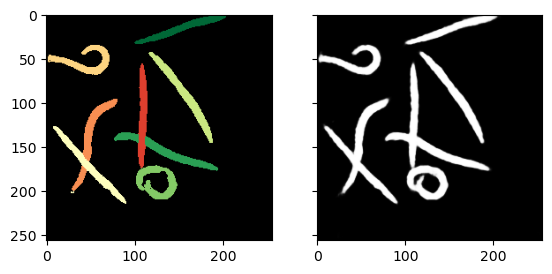

In [3]:
import time
from matplotlib import pyplot as plt
import numpy as np
from crossgoose.utils import normalize_image
from crossgoose.mask_utils import relabel
from crossgoose.my_display import get_custom_mask_cmap
from crossgoose.utils import imread
import torch

image_path = "../data/Dataset_v02/test/S00107_img.tif"
image_normalization = 'M1P1'

image = imread(image_path)

if len(image.shape) == 3:
    chan_dim = np.argmin(image.shape)
    image = np.mean(image, axis=chan_dim)
h, w = image.shape
image = normalize_image(image, image_normalization)

image = torch.tensor(image)
image = image.unsqueeze(dim=0).unsqueeze(dim=0).float()
start = time.perf_counter()
results = model.segment_image(image=image)
end = time.perf_counter()
print(f"ran detection in {end-start:.2f}s")

cmap_mask = get_custom_mask_cmap()
fig,axs = plt.subplots(1,2,sharex=True,sharey=True)
axs[0].imshow(relabel(results['mask'],shuffle=True),cmap=cmap_mask)
axs[1].imshow(results['cellprob'],cmap='gray')

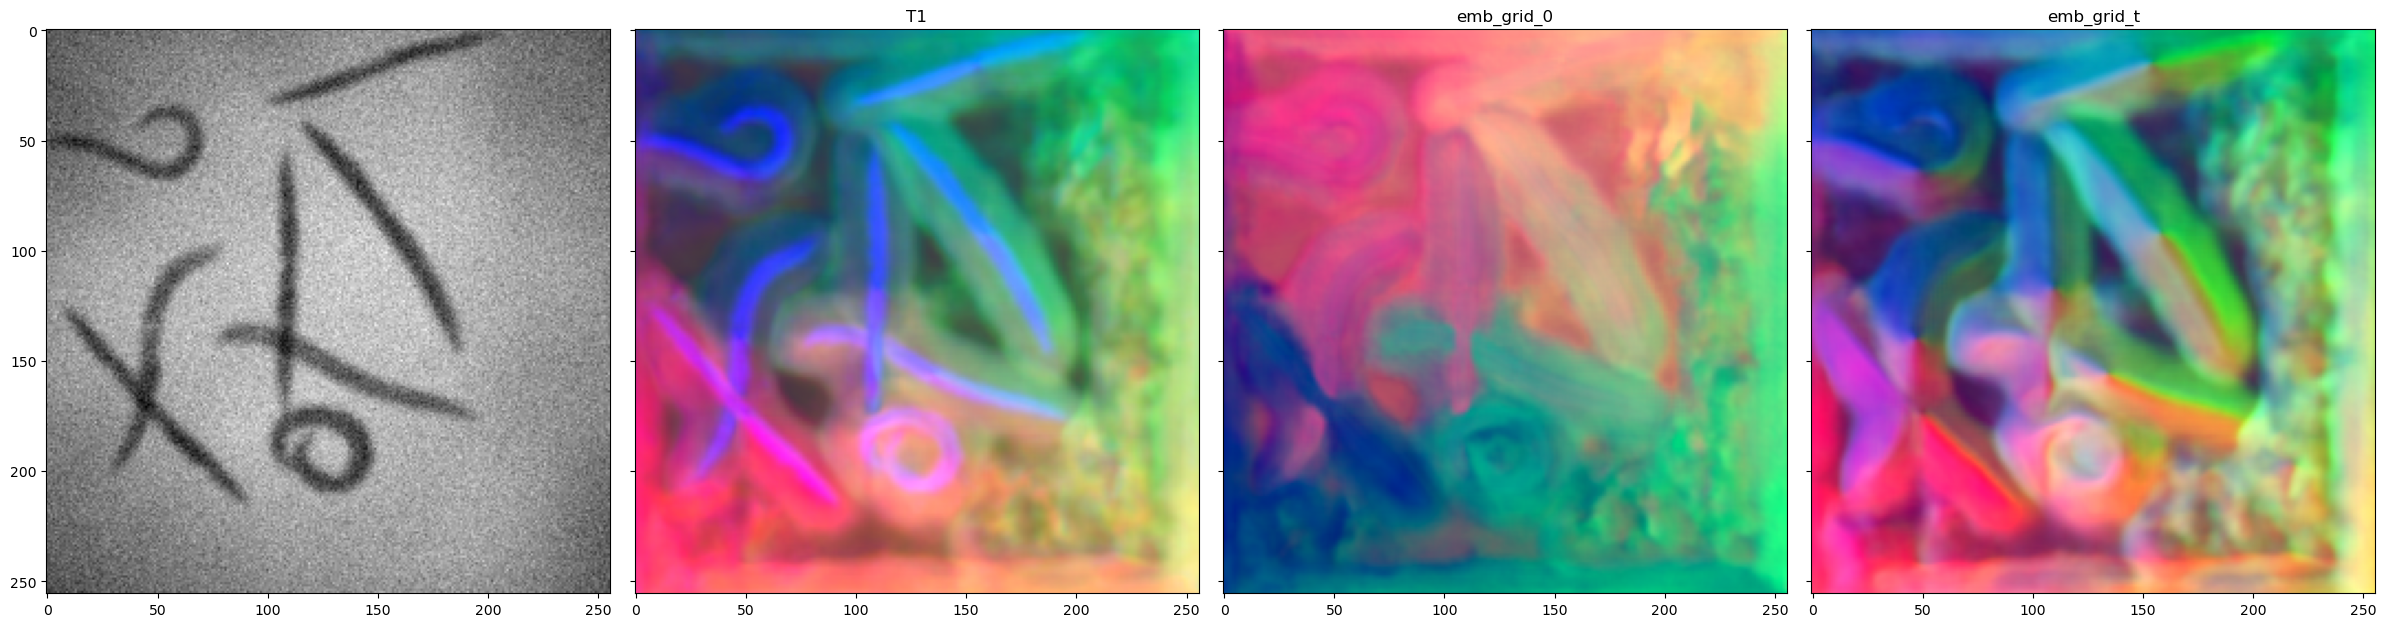

In [23]:
from sklearn.decomposition import PCA
from torch import nn
from crossgoose.cellpose.transforms import get_pad_yx
from crossgoose.utils import remap


image_path = "../data/Dataset_v02/test/S00107_img.tif"
image_normalization = 'M1P1'

image = imread(image_path)
image_np = image.copy()

if len(image.shape) == 3:
    chan_dim = np.argmin(image.shape)
    image = np.mean(image, axis=chan_dim)
h, w = image.shape
image = normalize_image(image, image_normalization)
image = torch.tensor(image)
image = image.unsqueeze(dim=0).unsqueeze(dim=0).float()

ypad1, ypad2, xpad1, xpad2 = get_pad_yx(
            h, w, div=16, extra=1, min_size=None)

image_padded = nn.functional.pad(
    image, (xpad1, xpad2, ypad1, ypad2), value=-1)

fg, last_pt, features = model.follow_flow(
    image_padded.to(model.device), n_steps=model.n_steps,
    skip_logging=True)
end = time.perf_counter()

fig,axs = plt.subplots(1,4,figsize=(4*6,6),sharex=True,sharey=True)
axs[0].imshow(image_np,cmap='gray')


for i,k in enumerate(['T1','emb_grid_0','emb_grid_t']):
    feat = features[k][0][:,ypad1:-ypad2, xpad1:-xpad2]
    d,h,w = feat.shape
    f_pca = PCA(n_components=3).fit_transform(feat.reshape((d,-1)).numpy().T).reshape((h,w,3))

    f_pca = (f_pca - np.mean(f_pca)) / (2*np.std(f_pca))
    f_pca_col = np.clip(f_pca / 2 + 0.5 ,0.0,1.0)

    axs[i+1].imshow(f_pca_col)
    axs[i+1].set_title(k)
fig.tight_layout()